# Loading and Preparing Data for NBA Statistics Analysis

In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
pd.set_option('display.max_columns',None)

data = pd.read_excel('../data/nba_player_data.xlsx')

In [2]:
data.sample(10)

,Year,Season_type,PLAYER_ID,RANK,PLAYER,TEAM_ID,TEAM,GP,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PTS,EFF
833,2002-03,Playoffs,952,25,Antoine Walker,1610612738,BOS,10,44.0,7.3,17.6,0.415,1.6,4.5,0.356,1.1,2.2,0.500,2.0,6.7,8.7,4.3,1.7,0.4,3.7,17.3,17.3
2226,2007-08,Regular%20Season,1729,60,Ricky Davis,1610612748,MIA,82,36.1,5.1,11.8,0.433,1.6,4.1,0.405,1.9,2.4,0.787,0.7,3.6,4.3,3.4,1.1,0.2,2.3,13.8,13.1
2373,2007-08,Playoffs,101108,6,Chris Paul,1610612740,NOH,12,40.5,9.3,18.4,0.502,0.4,1.8,0.238,5.2,6.6,0.785,1.3,3.6,4.9,11.3,2.3,0.2,1.8,24.1,30.3
6593,2020-21,Regular%20Season,1629027,14,Trae Young,1610612737,ATL,63,33.7,7.7,17.7,0.438,2.2,6.3,0.343,7.7,8.7,0.886,0.6,3.3,3.9,9.4,0.8,0.2,4.1,25.3,24.6
1830,2005-06,Playoffs,2592,103,James Jones,1610612756,PHX,20,17.7,1.4,4.1,0.341,0.4,1.3,0.308,1.1,1.3,0.846,0.8,2.8,3.6,0.3,0.3,0.9,0.5,4.3,6.0
4646,2014-15,Regular%20Season,200782,145,P.J. Tucker,1610612756,PHX,78,30.6,3.3,7.6,0.438,1.1,3.2,0.345,1.3,1.8,0.727,1.5,5.0,6.4,1.6,1.4,0.3,1.2,9.1,12.8
6355,2018-19,Regular%20Season,202697,189,Iman Shumpert,1610612745,HOU,62,23.9,2.7,7.2,0.374,1.5,4.4,0.348,0.6,0.7,0.800,0.4,2.5,3.0,1.8,1.0,0.4,0.8,7.5,8.1
6000,2017-18,Regular%20Season,202498,239,Lance Thomas,1610612752,NYK,73,18.5,1.4,3.7,0.382,0.7,1.7,0.403,0.6,0.7,0.830,0.6,1.8,2.4,0.6,0.4,0.2,0.6,4.1,4.7
7610,2022-23,Playoffs,201935,26,James Harden,1610612755,PHI,11,38.8,6.5,16.6,0.393,2.8,7.5,0.378,4.4,5.0,0.873,0.5,5.6,6.2,8.3,1.8,0.4,3.2,20.3,23.0
1263,2004-05,Regular%20Season,2202,16,Jason Richardson,1610612744,GSW,72,37.8,8.5,19.0,0.446,1.7,5.1,0.338,3.0,4.3,0.693,1.7,4.2,5.9,3.9,1.5,0.4,2.3,21.7,19.2


In [3]:
data.shape

(8109, 27)

# Data cleaning & Analysis preparation

In [4]:
data.isna().sum()

Year           0
Season_type    0
PLAYER_ID      0
RANK           0
PLAYER         0
TEAM_ID        0
TEAM           0
GP             0
MIN            0
FGM            0
FGA            0
FG_PCT         0
FG3M           0
FG3A           0
FG3_PCT        0
FTM            0
FTA            0
FT_PCT         0
OREB           0
DREB           0
REB            0
AST            0
STL            0
BLK            0
TOV            0
PTS            0
EFF            0
dtype: int64

In [5]:
data.drop(columns=['RANK','EFF'],inplace=True)

In [6]:
 data['season_start_year'] = data['Year'].str.split('-').str[0].astype(int)

In [7]:
data.TEAM.unique() 

array(['PHI', 'DET', 'LAL', 'TOR', 'SAC', 'ORL', 'BOS', 'GSW', 'NJN',
       'UTA', 'SEA', 'SAS', 'MIL', 'MIN', 'DAL', 'DEN', 'VAN', 'IND',
       'CHI', 'CHH', 'HOU', 'ATL', 'POR', 'NYK', 'WAS', 'PHX', 'LAC',
       'MIA', 'CLE', 'MEM', 'NOH', 'CHA', 'NOK', 'OKC', 'BKN', 'NOP'],
      dtype=object)

In [8]:
# dictionary mapping old team abbreviations to new ones
team_replacements = {
    'VAN': 'MEM',  # Vancouver Grizzlies -> Memphis Grizzlies
    'SEA': 'OKC',  # Seattle SuperSonics -> Oklahoma City Thunder
    'NJN': 'BKN',  # New Jersey Nets -> Brooklyn Nets
    'CHH': 'NOH',  # Charlotte Hornets -> New Orleans Hornets
    'NOK': 'NOP',  # New Orleans/Oklahoma City Hornets -> New Orleans Pelicans
    'NOH': 'NOP',  # New Orleans Hornets -> New Orleans Pelicans
}

In [9]:
# Replace old team abbreviations with new ones
data['TEAM'].replace(to_replace=team_replacements, inplace=True)

In [10]:
data['Season_type'].replace('Regular%20Season', 'Regular_Season', inplace=True)

In [11]:
rs_df = data[data['Season_type']=='Regular_Season']
playoff_df = data[data['Season_type']=='Playoffs']

In [12]:
data.columns

Index(['Year', 'Season_type', 'PLAYER_ID', 'PLAYER', 'TEAM_ID', 'TEAM', 'GP',
       'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA',
       'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PTS',
       'season_start_year'],
      dtype='object')

In [13]:
data = data[['season_start_year','Season_type', 'PLAYER_ID', 'PLAYER', 'TEAM_ID', 'TEAM', 'GP', 'MIN',
       'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA',
       'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PTS']]

In [14]:
total_cols = ['MIN','FGM','FGA','FG3M','FG3A','FTM','FTA','OREB','DREB','REB','AST', 'STL', 'BLK', 'TOV','PTS']

In [15]:
data.sample(10)

,season_start_year,Season_type,PLAYER_ID,PLAYER,TEAM_ID,TEAM,GP,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PTS
6781,2020,Regular_Season,1629731,Dean Wade,1610612739,CLE,63,19.2,2.1,4.9,0.431,1.2,3.4,0.366,0.5,0.6,0.769,0.6,2.8,3.4,1.2,0.6,0.3,0.5,6.0
3546,2011,Regular_Season,200751,Randy Foye,1610612746,LAC,65,25.9,3.9,9.9,0.398,2.0,5.1,0.386,1.1,1.3,0.859,0.4,1.7,2.1,2.2,0.7,0.4,1.1,11.0
5320,2015,Playoffs,203937,Kyle Anderson,1610612759,SAS,10,12.9,0.8,2.5,0.320,0.1,0.3,0.333,0.6,0.7,0.857,0.2,2.2,2.4,0.7,0.6,0.3,0.4,2.3
2548,2008,Regular_Season,200745,Andrea Bargnani,1610612761,TOR,78,31.4,5.5,12.3,0.450,1.5,3.7,0.409,2.8,3.4,0.831,0.9,4.4,5.3,1.2,0.4,1.2,1.7,15.4
5244,2015,Playoffs,203500,Steven Adams,1610612760,OKC,18,30.7,3.8,6.2,0.613,0.0,0.1,0.000,2.6,4.1,0.630,3.4,6.1,9.5,0.7,0.5,0.8,0.9,10.1
464,2001,Regular_Season,1751,Jahidi White,1610612764,WAS,71,19.0,2.1,3.9,0.538,0.0,0.0,0.000,1.2,2.2,0.539,2.2,4.0,6.3,0.2,0.4,1.1,0.9,5.4
5428,2016,Regular_Season,2200,Pau Gasol,1610612759,SAS,64,25.4,4.7,9.4,0.502,0.9,1.6,0.538,2.0,2.9,0.707,1.7,6.2,7.8,2.3,0.4,1.1,1.3,12.4
3619,2011,Regular_Season,202687,Bismack Biyombo,1610612766,CHA,63,23.1,2.0,4.4,0.464,0.0,0.0,0.000,1.1,2.3,0.483,1.8,4.0,5.8,0.4,0.3,1.8,1.1,5.2
399,2001,Regular_Season,1905,Andrei Kirilenko,1610612762,UTA,82,26.3,3.5,7.7,0.450,0.3,1.2,0.250,3.5,4.5,0.768,1.8,3.1,4.9,1.1,1.4,1.9,1.3,10.7
6093,2017,Playoffs,1938,Manu Ginobili,1610612759,SAS,5,21.4,3.0,7.4,0.405,1.2,3.6,0.333,1.8,2.2,0.818,0.2,2.8,3.0,3.2,1.4,0.2,1.4,9.0


In [16]:
data.to_csv("nba_player_data_cleaned.csv", index=False)

# Which player stats are correlated with each other?

In [86]:
data.sample(15)

,season_start_year,Season_type,PLAYER_ID,PLAYER,TEAM_ID,TEAM,GP,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PTS
1651,2005,Regular_Season,2735,Josh Childress,1610612737,ATL,74,30.4,3.8,6.8,0.552,0.4,0.9,0.492,2.1,2.7,0.766,1.8,3.4,5.2,1.8,1.2,0.5,1.4,10.0
6794,2020,Regular_Season,1629635,Sekou Doumbouya,1610612765,DET,56,15.5,1.9,5.0,0.379,0.5,2.1,0.226,0.8,1.1,0.703,0.7,1.9,2.6,0.8,0.4,0.2,0.8,5.1
6308,2018,Regular_Season,202391,Jeremy Lin,1610612761,TOR,74,19.4,3.2,7.3,0.440,0.7,2.5,0.294,2.4,2.8,0.838,0.3,2.1,2.4,3.1,0.6,0.2,1.7,9.6
6306,2018,Regular_Season,202357,Nemanja Bjelica,1610612758,SAC,77,23.2,3.7,7.7,0.479,1.3,3.3,0.401,0.9,1.2,0.761,1.6,4.1,5.8,1.9,0.7,0.7,1.1,9.6
344,2001,Regular_Season,1740,Rashard Lewis,1610612760,OKC,71,36.4,6.4,13.7,0.468,1.7,4.5,0.389,2.3,2.8,0.810,2.0,5.1,7.0,1.7,1.5,0.6,1.4,16.8
5586,2016,Regular_Season,1626245,Cristiano Felicio,1610612741,CHI,66,15.8,1.9,3.3,0.579,0.0,0.0,0.000,0.9,1.4,0.645,1.9,2.8,4.7,0.6,0.4,0.3,0.5,4.8
423,2001,Regular_Season,2048,Jamaal Magloire,1610612766,NOH,82,18.9,2.8,5.0,0.551,0.0,0.0,0.000,3.0,4.1,0.730,1.9,3.8,5.6,0.4,0.3,1.0,1.4,8.5
3172,2010,Regular_Season,2746,Josh Smith,1610612737,ATL,77,34.4,6.5,13.5,0.477,0.7,2.0,0.331,3.0,4.1,0.725,1.7,6.8,8.5,3.3,1.3,1.6,2.6,16.5
6585,2020,Regular_Season,1629029,Luka Doncic,1610612742,DAL,66,34.3,9.8,20.5,0.479,2.9,8.3,0.350,5.2,7.1,0.730,0.8,7.2,8.0,8.6,1.0,0.5,4.3,27.7
6413,2018,Regular_Season,1626170,Jerian Grant,1610612753,ORL,60,15.7,1.5,3.7,0.418,0.7,1.8,0.364,0.4,0.7,0.650,0.3,1.3,1.6,2.6,0.7,0.1,0.9,4.2


In [87]:
data.columns

Index(['season_start_year', 'Season_type', 'PLAYER_ID', 'PLAYER', 'TEAM_ID',
       'TEAM', 'GP', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT',
       'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK',
       'TOV', 'PTS'],
      dtype='object')

In [88]:
a = ['PLAYER','PLAYER_ID','MIN','FGM','FGA','FG3M','FG3A','FTM','FTA','OREB','DREB','REB','AST','STL','BLK', 'TOV','PTS','FG_PCT','FG3_PCT','FT_PCT']
stats_df = data[a]

In [89]:
stats_df.sample(10)

,PLAYER,PLAYER_ID,MIN,FGM,FGA,FG3M,FG3A,FTM,FTA,OREB,DREB,REB,AST,STL,BLK,TOV,PTS,FG_PCT,FG3_PCT,FT_PCT
215,Wally Szczerbiak,1887,35.8,4.5,9.3,0.0,0.3,5.0,6.3,1.0,3.5,4.5,2.5,1.3,0.8,3.0,14.0,0.486,0.000,0.800
2602,Mario Chalmers,201596,32.0,3.4,8.1,1.4,3.8,1.8,2.4,0.5,2.3,2.8,4.9,2.0,0.1,2.0,10.0,0.420,0.367,0.767
1819,Brian Cook,2567,11.1,2.6,6.6,0.6,1.6,0.6,0.6,1.6,1.6,3.1,1.1,0.1,0.0,0.4,6.3,0.391,0.364,1.000
5419,Robert Covington,203496,31.6,4.4,10.9,2.0,6.1,2.1,2.6,1.4,5.1,6.5,1.5,1.9,1.0,2.0,12.9,0.399,0.333,0.822
7276,Derrick White,1628401,25.4,2.8,7.7,1.1,3.6,1.8,2.2,0.3,2.7,3.0,2.7,0.9,0.6,1.3,8.5,0.364,0.313,0.824
2641,Roy Hibbert,201579,14.4,2.8,6.0,0.0,0.0,1.4,2.1,1.6,1.8,3.5,0.7,0.3,1.1,0.8,7.1,0.471,0.000,0.667
6701,Brandon Clarke,1629634,24.0,4.3,8.4,0.3,1.3,1.3,1.9,1.6,3.9,5.6,1.6,1.0,0.9,0.6,10.3,0.517,0.260,0.690
822,Jason Kidd,467,42.6,6.9,17.1,1.7,5.2,4.7,5.7,1.8,5.9,7.7,8.2,1.8,0.2,4.0,20.1,0.402,0.327,0.825
287,Othella Harrington,970,15.4,1.4,2.8,0.0,0.0,0.8,1.0,1.4,1.6,3.0,0.4,0.8,0.4,0.6,3.6,0.500,0.000,0.800
6571,Daniel Theis,1628464,6.0,0.7,2.0,0.0,0.3,0.3,0.3,0.6,0.9,1.4,0.0,0.1,0.1,0.1,1.7,0.357,0.000,1.000


# Selecting and Calculating Advanced NBA Statistics

In [90]:
columns_to_select = ['MIN', 'FGM', 'FGA', 'FG3M', 'FG3A', 'FTM', 'FTA', 'OREB', 'DREB', 'REB', 'AST', 'STL',
                     'BLK', 'TOV', 'PTS', 'FG_PCT', 'FG3_PCT', 'FT_PCT']
stats_df = data.loc[:, columns_to_select]

stats_df.loc[:, 'FG3A%'] = stats_df['FG3A'] / stats_df['FGA']
stats_df.loc[:, 'PTS/FGA'] = stats_df['PTS'] / stats_df['FGA']
stats_df.loc[:, 'FG3M/FGM'] = stats_df['FG3M'] / stats_df['FGM']
stats_df.loc[:, 'FTA/FGA'] = stats_df['FTA'] / stats_df['FGA']
stats_df.loc[:, 'TS%'] = 0.5 * stats_df['PTS'] / (stats_df['FGA'] + 0.475 * stats_df['FTA'])
stats_df.loc[:, 'AST/TOV'] = stats_df['AST'] / stats_df['TOV']
stats_df.loc[:, 'OREB%'] = stats_df['OREB'] / stats_df['REB']
stats_df.loc[:, 'DREB%'] = stats_df['DREB'] / stats_df['REB']
stats_df.loc[:, 'STL/TOV'] = stats_df['STL'] / stats_df['TOV']

In [91]:
stats_df.sample(10)

,MIN,FGM,FGA,FG3M,FG3A,FTM,FTA,OREB,DREB,REB,AST,STL,BLK,TOV,PTS,FG_PCT,FG3_PCT,FT_PCT,FG3A%,PTS/FGA,FG3M/FGM,FTA/FGA,TS%,AST/TOV,OREB%,DREB%,STL/TOV
930,11.7,0.7,2.2,0.4,1.4,0.3,0.4,0.3,0.5,0.8,1.3,0.7,0.1,0.6,2.1,0.333,0.267,0.750,0.636364,0.954545,0.571429,0.181818,0.439331,2.166667,0.375000,0.625000,1.166667
7233,30.5,5.5,15.6,2.3,6.5,1.5,2.3,0.7,2.0,2.7,2.7,1.0,0.3,2.0,14.6,0.349,0.347,0.640,0.416667,0.935897,0.418182,0.147436,0.437322,1.350000,0.259259,0.740741,0.500000
6762,16.0,2.5,5.6,1.7,4.1,0.3,0.3,0.4,2.1,2.4,0.8,0.3,0.1,0.7,6.9,0.437,0.425,0.957,0.732143,1.232143,0.680000,0.053571,0.600784,1.142857,0.166667,0.875000,0.428571
2661,18.4,2.0,4.6,0.8,2.1,0.5,0.7,1.1,1.7,2.8,0.9,0.6,0.5,0.6,5.4,0.446,0.369,0.808,0.456522,1.173913,0.400000,0.152174,0.547390,1.500000,0.392857,0.607143,1.000000
6070,24.6,4.2,9.4,1.4,3.4,2.0,2.6,0.2,2.4,2.6,2.4,1.0,0.0,1.0,11.8,0.447,0.412,0.769,0.361702,1.255319,0.333333,0.276596,0.554772,2.400000,0.076923,0.923077,1.000000
7339,6.0,0.0,1.2,0.0,0.5,0.0,0.0,0.3,0.2,0.5,0.5,0.2,0.0,0.2,0.0,0.000,0.000,0.000,0.416667,0.000000,NaN,0.000000,0.000000,2.500000,0.600000,0.400000,1.000000
2997,12.4,1.5,4.2,0.5,1.7,0.1,0.4,0.2,1.5,1.6,0.8,0.3,0.1,0.7,3.7,0.363,0.297,0.385,0.404762,0.880952,0.333333,0.095238,0.421412,1.142857,0.125000,0.937500,0.428571
6371,20.7,2.7,5.7,1.1,3.3,0.5,0.7,1.0,3.2,4.2,2.0,0.5,0.4,0.5,6.9,0.466,0.330,0.725,0.578947,1.210526,0.407407,0.122807,0.571902,4.000000,0.238095,0.761905,1.000000
7854,26.5,4.0,9.3,1.7,5.0,0.9,1.4,1.2,4.6,5.8,2.3,0.7,0.9,1.1,10.7,0.435,0.349,0.621,0.537634,1.150538,0.425000,0.150538,0.536879,2.090909,0.206897,0.793103,0.636364
1016,31.9,4.9,10.4,0.0,0.0,1.3,1.6,1.8,6.5,8.3,1.9,0.7,1.0,1.7,11.1,0.473,0.000,0.835,0.000000,1.067308,0.000000,0.153846,0.497312,1.117647,0.216867,0.783133,0.411765


In [92]:
stats_df.corr()

,MIN,FGM,FGA,FG3M,FG3A,FTM,FTA,OREB,DREB,REB,AST,STL,BLK,TOV,PTS,FG_PCT,FG3_PCT,FT_PCT,FG3A%,PTS/FGA,FG3M/FGM,FTA/FGA,TS%,AST/TOV,OREB%,DREB%,STL/TOV
MIN,1.000000,0.829397,0.844153,0.424509,0.443783,0.688417,0.684399,0.287031,0.610560,0.546628,0.599093,0.630987,0.257392,0.728720,0.831689,0.078805,0.182507,0.290908,-0.052101,0.153680,-0.045216,0.079347,0.157673,0.100503,-0.179890,0.168453,-0.124098
FGM,0.829397,1.000000,0.968557,0.422535,0.437535,0.802074,0.792689,0.262563,0.586348,0.520303,0.593704,0.525287,0.240479,0.773305,0.983588,0.200807,0.180577,0.282159,-0.132667,0.222710,-0.139931,0.074653,0.240674,0.027826,-0.156802,0.148058,-0.241077
FGA,0.844153,0.968557,1.000000,0.504353,0.543375,0.797913,0.771192,0.154431,0.510620,0.427300,0.631857,0.562638,0.148407,0.788411,0.970757,0.004597,0.228131,0.319675,-0.032847,0.074206,-0.043728,0.009920,0.094964,0.067422,-0.223235,0.214748,-0.224155
FG3M,0.424509,0.422535,0.504353,1.000000,0.972465,0.244149,0.163940,-0.401227,-0.003876,-0.142396,0.404432,0.333181,-0.249845,0.285204,0.498546,-0.212523,0.597714,0.339515,0.700494,0.044614,0.705917,-0.296702,0.227634,0.250071,-0.491828,0.487646,0.032629
FG3A,0.443783,0.437535,0.543375,0.972465,1.000000,0.276297,0.196196,-0.410643,0.000976,-0.142141,0.437982,0.368726,-0.257635,0.326563,0.514202,-0.289213,0.545385,0.342242,0.712106,-0.035050,0.677781,-0.300240,0.129344,0.257182,-0.501323,0.497267,0.030384
FTM,0.688417,0.802074,0.797913,0.244149,0.276297,1.000000,0.975447,0.246430,0.511014,0.459658,0.526966,0.468597,0.234905,0.753771,0.870535,0.100866,0.062041,0.302446,-0.203577,0.345462,-0.208148,0.440987,0.186076,-0.030495,-0.095928,0.089981,-0.240550
FTA,0.684399,0.792689,0.771192,0.163940,0.196196,0.975447,1.000000,0.344249,0.573597,0.539483,0.490304,0.458751,0.319760,0.754576,0.846886,0.158204,-0.010193,0.187978,-0.274957,0.366540,-0.276147,0.517089,0.170497,-0.072971,-0.036217,0.029949,-0.247621
OREB,0.287031,0.262563,0.154431,-0.401227,-0.410643,0.246430,0.344249,1.000000,0.675300,0.841741,-0.125770,0.056635,0.637243,0.192977,0.200467,0.430971,-0.418699,-0.164431,-0.591012,0.260451,-0.560838,0.366519,0.120750,-0.336185,0.625005,-0.628762,-0.123622
DREB,0.610560,0.586348,0.510620,-0.003876,0.000976,0.511014,0.573597,0.675300,1.000000,0.966395,0.211223,0.297226,0.598428,0.496227,0.554520,0.313618,-0.135310,0.016830,-0.326048,0.264284,-0.313302,0.262410,0.184893,-0.172643,0.001267,-0.010253,-0.173469
REB,0.546628,0.520303,0.427300,-0.142396,-0.142141,0.459658,0.539483,0.841741,0.966395,1.000000,0.110727,0.237231,0.659589,0.430113,0.475446,0.379452,-0.244762,-0.044926,-0.444202,0.284067,-0.424480,0.319486,0.177387,-0.243573,0.217625,-0.227821,-0.169956


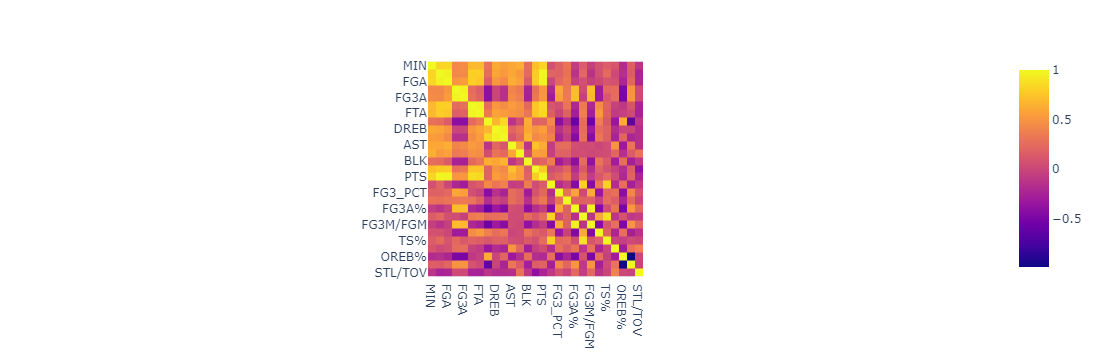

In [93]:
fig = px.imshow(stats_df.corr())
fig.show()

# How are minutes played distributed?

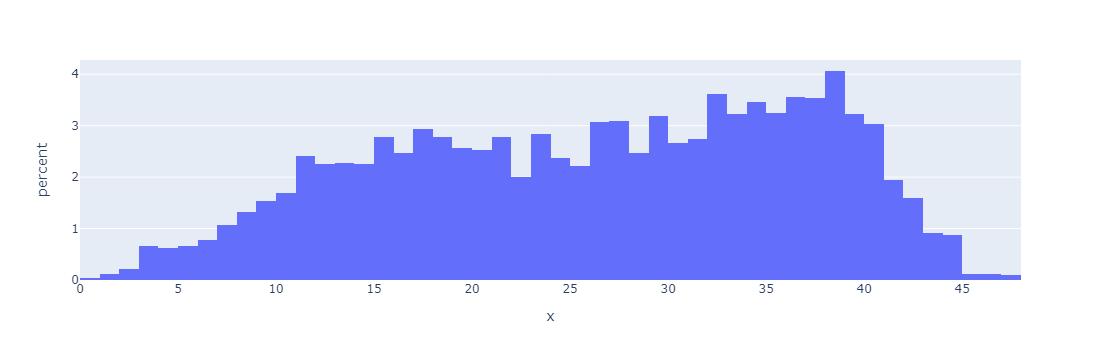

In [94]:
fig = px.histogram(x=playoff_df['MIN'], histnorm='percent')
fig.show()

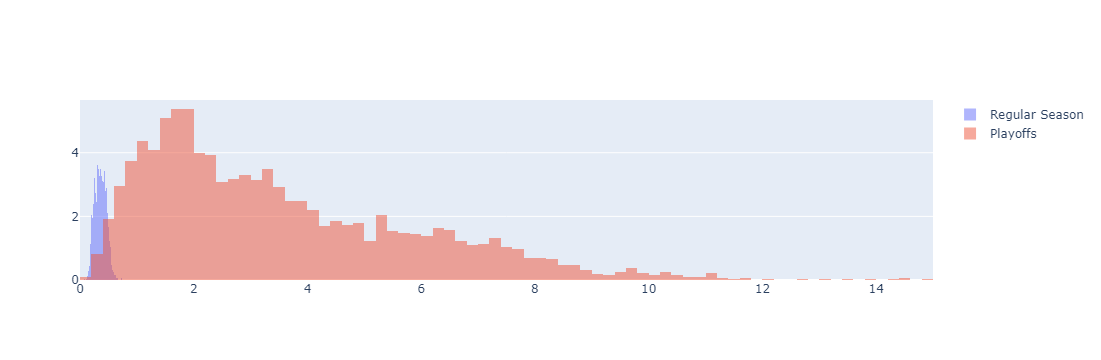

In [95]:
fig = go.Figure()
fig.add_trace(go.Histogram(x=rs_df['MIN']/rs_df['GP'], histnorm='percent', name='Regular Season'))
fig.add_trace(go.Histogram(x=playoff_df['MIN']/playoff_df['GP'], histnorm='percent', name='Playoffs'))
fig.update_layout(barmode='overlay')
fig.update_traces(opacity=0.5)
fig.show()

# How has the game evolved over the past 20 Years?

In [96]:
data.sample()

,season_start_year,Season_type,PLAYER_ID,PLAYER,TEAM_ID,TEAM,GP,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PTS
5634,2016,Playoffs,202362,Lance Stephenson,1610612754,IND,4,26.8,6.8,13.3,0.509,1.8,4.5,0.389,0.8,1.0,0.75,0.3,5.0,5.3,2.8,0.5,0.0,1.0,16.0


In [97]:
change_df = data.groupby('season_start_year')[total_cols].sum().reset_index()
change_df['POSS_est'] = change_df['FGA']-change_df['OREB']+change_df['TOV']+0.44*change_df['FTA']
change_df = change_df[list(change_df.columns[0:2])+['POSS_est']+list(change_df.columns[2:-1])]

change_df['FG3A%'] = change_df['FG3A'] / change_df['FGA']
change_df['PTS/FGA'] = change_df['PTS'] / change_df['FGA']
change_df['FG3M/FGM'] = change_df['FG3M'] / change_df['FGM']
change_df['FTA/FGA'] = change_df['FTA'] / change_df['FGA']
change_df['TS%'] = 0.5 * change_df['PTS'] / (change_df['FGA'] + 0.475 * change_df['FTA'])
change_df['AST/TOV'] = change_df['AST'] / change_df['TOV']
change_df['OREB%'] = change_df['OREB'] / change_df['REB']
change_df['DREB%'] = change_df['DREB'] / change_df['REB']
change_df['STL/TOV'] = change_df['STL'] / change_df['TOV']

change_df

,season_start_year,MIN,POSS_est,FGM,FGA,FG3M,FG3A,FTM,FTA,OREB,DREB,REB,AST,STL,BLK,TOV,PTS,FG3A%,PTS/FGA,FG3M/FGM,FTA/FGA,TS%,AST/TOV,OREB%,DREB%,STL/TOV
0,2000,8684.9,3499.020,1318.5,3000.4,190.1,539.3,718.9,948.0,425.4,1103.6,1528.3,785.0,269.4,193.8,506.9,3544.1,0.179743,1.181209,0.144179,0.315958,0.513533,1.548629,0.278348,0.722110,0.531466
1,2001,8713.3,3430.088,1310.2,2958.7,199.4,561.2,708.9,940.2,435.8,1115.3,1549.6,771.1,275.9,191.2,493.5,3527.0,0.189678,1.192078,0.152191,0.317775,0.517870,1.562513,0.281234,0.719734,0.559068
2,2002,8749.7,3454.100,1306.1,2946.3,196.0,560.0,728.1,950.0,424.8,1108.2,1532.2,772.4,283.1,177.0,514.6,3534.0,0.190069,1.199471,0.150065,0.322438,0.520081,1.500972,0.277248,0.723274,0.550136
3,2003,8707.1,3375.680,1255.0,2886.3,194.4,571.2,675.2,904.5,427.5,1101.1,1528.3,754.0,286.3,182.0,518.9,3377.0,0.197900,1.170010,0.154900,0.313377,0.509207,1.453074,0.279723,0.720474,0.551744
4,2004,8414.4,3320.396,1280.5,2844.0,209.6,590.3,721.8,953.4,414.7,1020.6,1435.4,729.3,253.7,174.6,471.6,3491.9,0.207560,1.227813,0.163686,0.335232,0.529579,1.546438,0.288909,0.711021,0.537956
5,2005,8675.1,3431.412,1318.9,2882.2,221.2,615.3,753.6,987.3,371.3,1049.2,1419.2,733.6,240.7,148.4,486.1,3610.8,0.213483,1.252793,0.167716,0.342551,0.538738,1.509154,0.261626,0.739290,0.495166
6,2006,8730.5,3470.048,1324.0,2913.6,233.5,650.6,727.2,969.2,391.3,1086.0,1476.8,753.6,259.1,164.8,521.3,3607.0,0.223298,1.237987,0.176360,0.332647,0.534534,1.445617,0.264965,0.735374,0.497027
7,2007,9111.3,3576.804,1404.4,3086.8,244.6,687.0,758.3,999.1,434.2,1162.9,1596.7,782.7,262.6,183.6,484.6,3810.8,0.222561,1.234547,0.174167,0.323669,0.535018,1.615147,0.271936,0.728315,0.541890
8,2008,8648.3,3404.900,1324.7,2889.7,246.3,672.3,715.6,922.5,362.9,1067.1,1427.9,739.8,254.4,161.4,472.2,3611.8,0.232654,1.249888,0.185929,0.319237,0.542657,1.566709,0.254149,0.747321,0.538755
9,2009,8832.6,3531.968,1380.8,3006.2,239.2,672.8,739.2,964.7,384.8,1125.0,1508.4,765.3,256.7,176.2,486.1,3736.8,0.223804,1.243031,0.173233,0.320903,0.539309,1.574367,0.255105,0.745823,0.528081


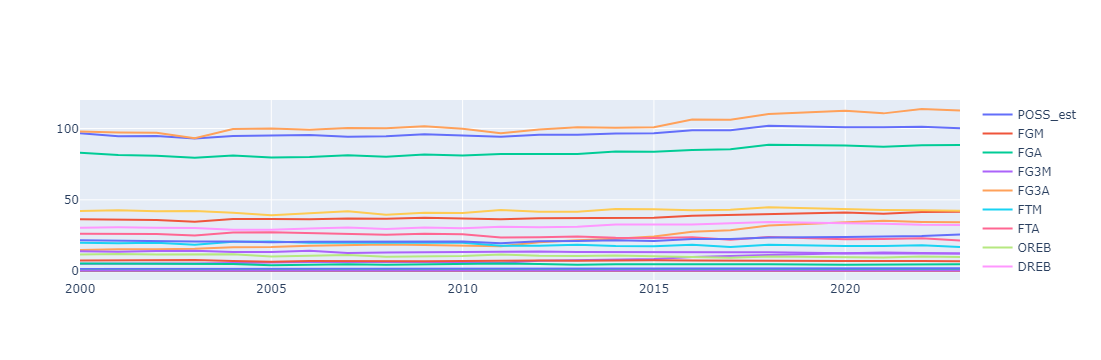

In [99]:
change_per_48_df = change_df.copy()
for col in change_per_48_df.columns[2:17]:
    change_per_48_df[col] = (change_per_48_df[col]/change_per_48_df['MIN'])*48*5

change_per_48_df.drop(columns='MIN', inplace=True)

fig = go.Figure()
for col in change_per_48_df.columns[1:]:
    fig.add_trace(go.Scatter(x=change_per_48_df['season_start_year'],
                             y=change_per_48_df[col], name=col))

fig.show()

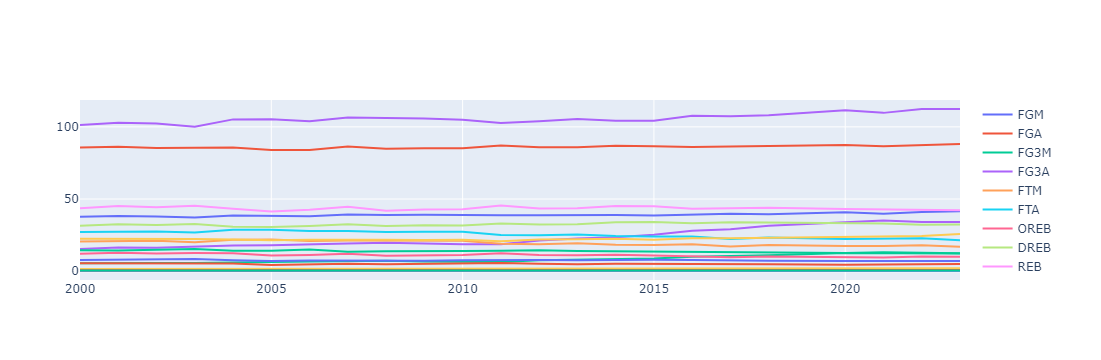

In [100]:
change_per_100_df = change_df.copy()
change_per_100_df

for col in change_per_100_df.columns[3:17]:
    change_per_100_df[col] = (change_per_100_df[col]/change_per_100_df['POSS_est'])*100

change_per_100_df.drop(columns=['MIN','POSS_est'], inplace=True)
change_per_100_df

fig = go.Figure()
for col in change_per_100_df.columns[1:]:
    fig.add_trace(go.Scatter(x=change_per_100_df['season_start_year'],
                             y=change_per_100_df[col], name=col))

fig.show()

# Compare Regular Season (RS) to Playoffs

In [101]:
rs_change_df = rs_df.groupby('season_start_year')[total_cols].sum().reset_index()
playoffs_change_df = playoff_df.groupby('season_start_year')[total_cols].sum().reset_index()

for i in [rs_change_df,playoffs_change_df]:
    i['POSS_est'] = i['FGA']-i['OREB']+i['TOV']+0.44*i['FTA']
    i['POSS_per_48'] = (i['POSS_est']/i['MIN'])*48*5

    i['FG3A%'] = i['FG3A'] / i['FGA']
    i['PTS/FGA'] = i['PTS'] / i['FGA']
    i['FG3M/FGM'] = i['FG3M'] / i['FGM']
    i['FTA/FGA'] = i['FTA'] / i['FGA']
    i['TS%'] = 0.5 * i['PTS'] / (i['FGA'] + 0.475 * i['FTA'])
    i['AST/TOV'] = i['AST'] / i['TOV']
    i['OREB%'] = i['OREB'] / i['REB']
    i['DREB%'] = i['DREB'] / i['REB']
    i['STL/TOV'] = i['STL'] / i['TOV']
    for col in total_cols:
        i[col] = 100*i[col]/i['POSS_est']

    i.drop(columns=['MIN','POSS_est'], inplace=True)

rs_change_df

,season_start_year,FGM,FGA,FG3M,FG3A,FTM,FTA,OREB,DREB,REB,AST,STL,BLK,TOV,PTS,POSS_per_48,FG3A%,PTS/FGA,FG3M/FGM,FTA/FGA,TS%,AST/TOV,OREB%,DREB%,STL/TOV
0,2000,38.194188,85.160156,5.281066,14.749095,20.475381,27.182099,11.902529,31.198551,43.129498,23.198801,7.838713,5.366321,14.782250,102.125878,98.669232,0.173192,1.199221,0.138269,0.319188,0.520670,1.569369,0.275972,0.723369,0.530279
1,2001,39.299276,86.809069,5.821002,16.055345,20.032862,26.324754,12.704011,31.930348,44.624340,23.284007,8.105319,5.710793,14.312050,104.437387,95.878004,0.184950,1.203070,0.148120,0.303249,0.525797,1.626881,0.284688,0.715537,0.566328
2,2002,38.269931,85.638642,5.382377,15.439921,20.295452,26.479964,12.155438,31.672486,43.813684,23.081567,8.306137,5.092848,14.865611,102.208198,96.259326,0.180292,1.193482,0.140642,0.309206,0.520320,1.552682,0.277435,0.722890,0.558748
3,2003,38.239948,85.797652,5.893882,16.772964,20.196838,26.778507,12.611100,32.280802,44.906963,23.083534,8.383972,5.547478,15.030905,102.580657,94.246321,0.195494,1.195611,0.154129,0.312112,0.520622,1.535738,0.280827,0.718837,0.557782
4,2004,38.705771,85.476948,6.224223,17.271325,21.766882,28.543460,12.427989,30.676164,43.119497,23.050596,7.804573,5.012111,14.391918,105.397532,95.343850,0.202058,1.233052,0.160809,0.333932,0.532122,1.601635,0.288222,0.711422,0.542289
5,2005,38.540236,84.403409,6.583835,18.005866,21.472834,28.119882,10.726692,30.147548,40.815890,22.299460,7.337524,4.293594,13.950535,105.132280,96.480019,0.213331,1.245593,0.170830,0.333161,0.537704,1.598466,0.262807,0.738623,0.525967
6,2006,38.702082,83.711097,6.624725,18.148323,21.164896,27.853178,11.020022,30.630185,41.630650,22.636513,7.475427,4.717977,15.053526,105.228008,96.979004,0.216797,1.257038,0.171172,0.332730,0.542741,1.503735,0.264709,0.735760,0.496590
7,2007,39.955332,86.219878,7.125647,19.358538,20.537830,26.865187,11.720352,32.357968,44.069248,22.302233,7.606436,4.948492,13.679791,107.574141,96.149673,0.224525,1.247672,0.178340,0.311589,0.543409,1.630305,0.265953,0.734253,0.556034
8,2008,39.582198,85.190768,7.236566,19.289311,20.927501,26.825966,10.911424,31.046887,41.884518,22.550931,7.487460,4.580043,13.917231,107.372738,96.912133,0.226425,1.260380,0.182824,0.314893,0.548194,1.620361,0.260512,0.741250,0.537999
9,2009,39.730552,85.383816,6.631935,18.444482,20.036710,26.034572,10.788637,31.680172,42.407749,22.056351,7.374036,4.790775,13.949609,106.059297,98.241224,0.216018,1.242148,0.166923,0.304912,0.542501,1.581145,0.254402,0.747037,0.528620


In [102]:
playoffs_change_df

,season_start_year,FGM,FGA,FG3M,FG3A,FTM,FTA,OREB,DREB,REB,AST,STL,BLK,TOV,PTS,POSS_per_48,FG3A%,PTS/FGA,FG3M/FGM,FTA/FGA,TS%,AST/TOV,OREB%,DREB%,STL/TOV
0,2000,36.902682,86.646720,5.664032,16.422811,20.652819,26.958199,12.545903,32.060151,44.512374,21.272548,7.487187,5.800949,14.037576,100.014124,93.832467,0.189538,1.154275,0.153486,0.311128,0.502827,1.515400,0.281852,0.720253,0.533368
1,2001,36.663068,85.489041,5.802487,16.786761,21.550101,28.921770,12.706888,33.329428,45.945652,21.361799,7.957497,5.384038,14.492268,100.581086,92.597223,0.196362,1.176538,0.158265,0.338310,0.506824,1.474013,0.276563,0.725410,0.549086
2,2002,37.098508,84.766898,6.131126,17.421008,22.305125,29.104291,12.522045,32.726555,45.211487,21.236261,8.023907,5.173601,14.949259,102.477391,92.468259,0.205517,1.208932,0.165266,0.343345,0.519707,1.420556,0.276966,0.723855,0.536743
3,2003,35.648627,85.078307,5.564452,17.134177,19.721286,26.817769,12.740428,33.104878,45.801946,21.260544,8.621288,5.166991,15.862302,96.380649,91.371546,0.201393,1.132846,0.156092,0.315213,0.492659,1.340319,0.278163,0.722783,0.543508
4,2004,38.362591,85.903781,6.438938,18.503705,21.697535,28.956907,12.577538,30.824858,43.387746,20.408283,7.405877,5.611179,13.932719,104.832353,93.807387,0.215400,1.220346,0.167844,0.337085,0.525959,1.464774,0.289887,0.710451,0.531546
5,2005,38.280261,83.383035,6.240635,17.819996,22.693220,29.748483,10.961116,31.217724,42.171567,20.002037,6.531574,4.371354,14.488748,105.370729,92.705420,0.213712,1.263695,0.163025,0.356769,0.540288,1.380522,0.259917,0.740255,0.450803
6,2006,37.369795,84.327709,6.878738,19.611422,20.657270,28.041385,11.644720,32.252857,43.890558,20.397563,7.454306,4.794059,14.978802,102.107140,93.200098,0.232562,1.210837,0.184072,0.332529,0.522836,1.361762,0.265313,0.734847,0.497657
7,2007,38.153418,86.430064,6.377123,18.963743,22.265271,29.648158,12.812552,32.760194,45.558170,21.208490,6.916446,5.429665,13.337298,104.883638,91.267448,0.219411,1.213509,0.167144,0.343031,0.521742,1.590164,0.281235,0.719085,0.518579
8,2008,37.903522,84.391999,7.229435,20.420240,21.149014,27.489345,10.282997,31.774535,42.013806,20.507693,7.448068,4.977525,13.795687,104.156342,91.115934,0.241969,1.234197,0.190733,0.325734,0.534412,1.486529,0.244753,0.756288,0.539884
9,2009,38.128815,84.704564,6.985649,19.966127,22.282796,29.254189,11.055860,32.112603,43.161334,21.078128,7.106829,5.289135,13.479452,105.404897,92.718927,0.235715,1.244383,0.183212,0.345367,0.534506,1.563723,0.256152,0.744013,0.527234


In [103]:
comp_change_df = round(100*(playoffs_change_df-rs_change_df)/rs_change_df,3)
comp_change_df['season_start_year'] = list(range(2000,2023))
comp_change_df

,season_start_year,FGM,FGA,FG3M,FG3A,FTM,FTA,OREB,DREB,REB,AST,STL,BLK,TOV,PTS,POSS_per_48,FG3A%,PTS/FGA,FG3M/FGM,FTA/FGA,TS%,AST/TOV,OREB%,DREB%,STL/TOV
0,2000,-3.381,1.746,7.252,11.348,0.867,-0.824,5.405,2.762,3.206,-8.303,-4.484,8.099,-5.038,-2.068,-4.902,9.438,-3.748,11.005,-2.525,-3.427,-3.439,2.131,-0.431,0.582
1,2001,-6.708,-1.521,-0.318,4.556,7.574,9.865,0.023,4.382,2.961,-8.255,-1.824,-5.722,1.259,-3.692,-3.422,6.170,-2.205,6.849,11.562,-3.609,-9.396,-2.854,1.380,-3.045
2,2002,-3.061,-1.018,13.911,12.831,9.902,9.911,3.016,3.328,3.190,-7.995,-3.398,1.586,0.563,0.263,-3.938,13.991,1.294,17.508,11.041,-0.118,-8.510,-0.169,0.133,-3.938
3,2003,-6.776,-0.838,-5.589,2.154,-2.355,0.147,1.026,2.553,1.993,-7.897,2.831,-6.859,5.531,-6.044,-3.050,3.017,-5.250,1.273,0.993,-5.371,-12.725,-0.949,0.549,-2.559
4,2004,-0.887,0.499,3.450,7.135,-0.319,1.448,1.203,0.485,0.622,-11.463,-5.108,11.952,-3.191,-0.536,-1.611,6.603,-1.030,4.375,0.944,-1.158,-8.545,0.578,-0.137,-1.981
5,2005,-0.675,-1.209,-5.213,-1.032,5.683,5.792,2.185,3.550,3.321,-10.303,-10.984,1.811,3.858,0.227,-3.912,0.179,1.453,-4.569,7.086,0.480,-13.635,-1.099,0.221,-14.291
6,2006,-3.442,0.737,3.834,8.062,-2.398,0.676,5.669,5.298,5.428,-9.891,-0.283,1.613,-0.496,-2.966,-3.897,7.272,-3.675,7.536,-0.060,-3.667,-9.441,0.228,-0.124,0.215
7,2007,-4.510,0.244,-10.505,-2.039,8.411,10.359,9.319,1.243,3.379,-4.904,-9.071,9.724,-2.504,-2.501,-5.078,-2.278,-2.738,-6.278,10.091,-3.987,-2.462,5.746,-2.066,-6.736
8,2008,-4.241,-0.938,-0.099,5.863,1.058,2.473,-5.759,2.344,0.309,-9.061,-0.526,8.679,-0.873,-2.996,-5.981,6.865,-2.077,4.326,3.443,-2.514,-8.259,-6.049,2.029,0.350
9,2009,-4.031,-0.796,5.334,8.250,11.210,12.367,2.477,1.365,1.777,-4.435,-3.624,10.402,-3.370,-0.617,-5.621,9.118,0.180,9.758,13.268,-1.474,-1.102,0.688,-0.405,-0.262


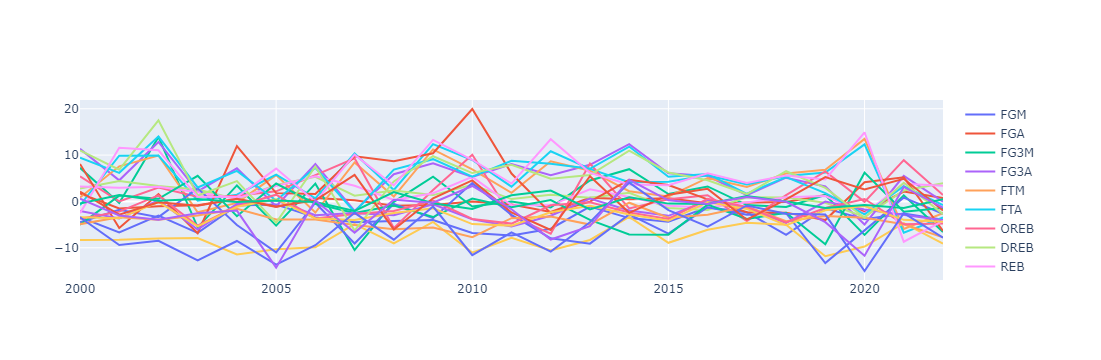

In [104]:
fig = go.Figure()
for col in comp_change_df.columns[1:]:
    fig.add_trace(go.Scatter(x=comp_change_df['season_start_year'],
                             y=comp_change_df[col], name=col))

fig.show()